In [8]:
%load_ext autoreload
%autoreload 
from methods.constants import DataGenerationSettings
import pandas as pd
import pickle
import networkx as nx
from networkx.algorithms import community
from tqdm import tqdm
import numpy as np
from methods.methods_est import calculate_lr_results

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
dgp_settings = DataGenerationSettings()

In [12]:
# Degree Centrality: The number of edges connected to a node (i.e., the degree of the node).
# Betweenness Centrality: How often a node appears on the shortest path between other nodes.
# Community: The group or cluster a node belongs to in the network.

In [151]:
# watts_strogatz_graph 0.7

In [1]:
from node2vec import Node2Vec  # pip install node2vec

/Users/polinarevina/Library/Caches/pypoetry/virtualenvs/simulations-notebooks-2NAxyaa6-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [99]:
for i in [0.3, 0.6, 0.9]:
    with open(f'data/adj_matrix/dict_adj_matrix_100_watts_strogatz_graph_{round(i, 2)}.pkl', 'rb') as file:
        adj_matrix_dict = pickle.load(file)
    
    degree_centrality_list = []
    betweenness_centrality_list = []
    node_community_df = pd.DataFrame(columns=["node", "community"])    

    for sim in tqdm(range(dgp_settings.n_sim)):
        adj_matrix = adj_matrix_dict[sim]
        G = nx.from_numpy_array(adj_matrix)
        degree_centrality = list(nx.degree_centrality(G).values())
        betweenness_centrality = list(nx.betweenness_centrality(G).values())
        communities = list(nx.algorithms.community.girvan_newman(G))
        best_community = communities[0]
        node_community = {node: idx for idx, community_nodes in enumerate(best_community) for node in community_nodes}

        degree_centrality_list.extend(degree_centrality)
        betweenness_centrality_list.extend(betweenness_centrality)
        node_community_df_sim = pd.DataFrame(list(node_community.items()), columns=['node', 'community']) 
        node_community_df_sim['n_sim'] = sim
        node_community_df = pd.concat([node_community_df, node_community_df_sim], axis=0) 

    df = pd.DataFrame({
        "n_sim": np.repeat(np.arange(100), 100),
        "degree_centrality": degree_centrality_list,
        "betweenness_centrality": betweenness_centrality_list,
    })
    df.to_parquet(f"data/network_features/network_features_1000_features_{round(i, 2)}.parquet")
    node_community_df.to_parquet(f"data/network_features/network_features_1000_community_{round(i, 2)}.parquet")
        

100%|██████████| 100/100 [00:30<00:00,  3.33it/s]


| Network   | Neigbour influence   | Effect difference  |
|:-------|:--------:|-------:|
| Watts Srogatz (n_edges=3, p=0.7) | 0.6   | 12% |
| Watts Srogatz (n_edges=3, p=0.7) | 0.9   | 72% |

100%|██████████| 100/100 [00:00<00:00, 180.71it/s]


Pecrentage difference between true and estimated effect: 11.874


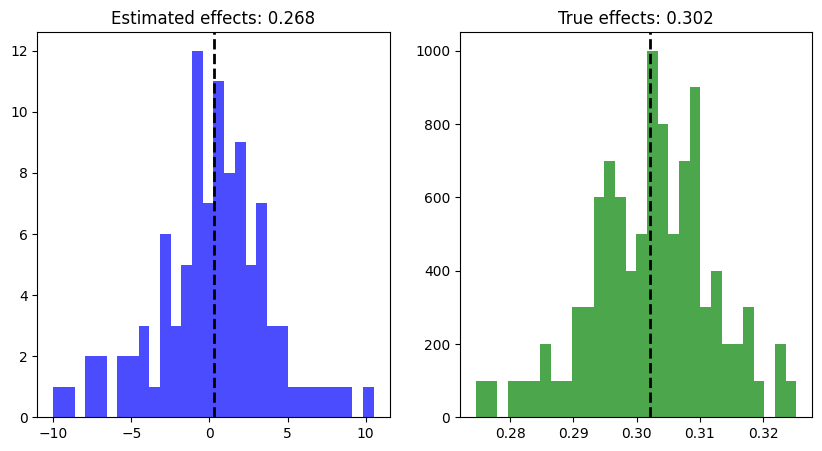

In [141]:
network_features_df = pd.read_parquet('data/network_features/network_features_1000_features_0.6.parquet')
node_community_df = pd.read_parquet('data/network_features/network_features_1000_community_0.6.parquet')
individ_data = pd.read_parquet('data/individ_data/individ_data_watts_strogatz_graph_100_0.6.parquet')

calculate_lr_results(
    individ_data=individ_data,
    n_sim=dgp_settings.n_sim,
    n_features=dgp_settings.n_features,
    additional_feature_names=["degree_centrality", "betweenness_centrality"],
    network_features_df=network_features_df,
    node_community_df=node_community_df
)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:00<00:00, 178.08it/s]


Pecrentage difference between true and estimated effect: 71.279


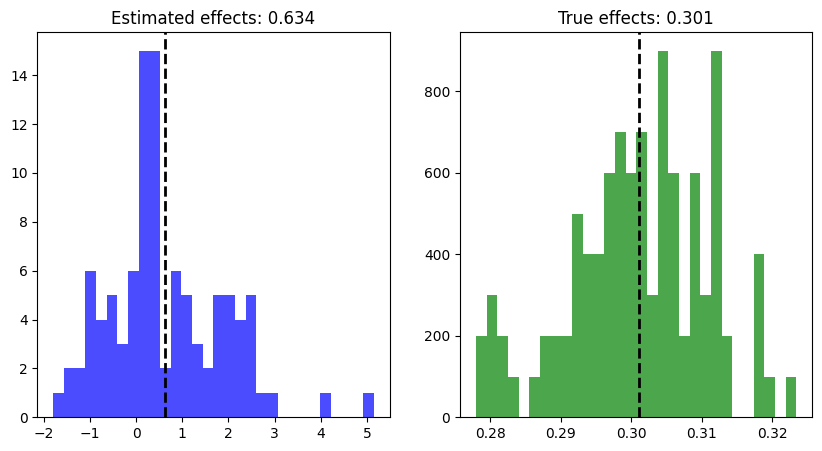

In [145]:
network_features_df = pd.read_parquet('data/network_features/network_features_1000_features_0.3.parquet')
node_community_df = pd.read_parquet('data/network_features/network_features_1000_community_0.3.parquet')
individ_data = pd.read_parquet('data/individ_data/individ_data_watts_strogatz_graph_100_0.3.parquet')

calculate_lr_results(
    individ_data=individ_data,
    n_sim=dgp_settings.n_sim,
    n_features=dgp_settings.n_features,
    additional_feature_names=["degree_centrality", "betweenness_centrality", "community"],
    network_features_df=network_features_df,
    node_community_df=node_community_df
)

In [6]:
# erdos_renyi_graph 0.2

In [10]:
for i in [0.3, 0.6, 0.9]:
    with open(f'data/adj_matrix/dict_adj_matrix_100_erdos_renyi_graph_{round(i, 2)}.pkl', 'rb') as file:
        adj_matrix_dict = pickle.load(file)
    
    degree_centrality_list = []
    betweenness_centrality_list = []
    node_community_df = pd.DataFrame(columns=["node", "community"])    

    for sim in tqdm(range(dgp_settings.n_sim)):
        adj_matrix = adj_matrix_dict[sim]
        G = nx.from_numpy_array(adj_matrix)
        degree_centrality = list(nx.degree_centrality(G).values())
        betweenness_centrality = list(nx.betweenness_centrality(G).values())
        # communities = list(nx.algorithms.community.girvan_newman(G))
        # best_community = communities[0]
        # node_community = {node: idx for idx, community_nodes in enumerate(best_community) for node in community_nodes}

        degree_centrality_list.extend(degree_centrality)
        betweenness_centrality_list.extend(betweenness_centrality)
        node_community_df_sim = pd.DataFrame(list(node_community.items()), columns=['node', 'community']) 
        # node_community_df_sim['n_sim'] = sim
        # node_community_df = pd.concat([node_community_df, node_community_df_sim], axis=0) 

    df = pd.DataFrame({
        "n_sim": np.repeat(np.arange(100), 100),
        "degree_centrality": degree_centrality_list,
        "betweenness_centrality": betweenness_centrality_list,
    })
    df.to_parquet(f"data/network_features/network_features_erdos_renyi_graph_100_features_{round(i, 2)}.parquet")
    node_community_df.to_parquet(f"data/network_features/network_features_erdos_renyi_graph_100_community_{round(i, 2)}.parquet")
        

 80%|████████  | 80/100 [26:07<06:31, 19.59s/it]


KeyboardInterrupt: 

In [11]:
df = pd.DataFrame({
        "n_sim": np.repeat(np.arange(100), 100),
        "degree_centrality": degree_centrality_list,
        "betweenness_centrality": betweenness_centrality_list,
    })

ValueError: All arrays must be of the same length